In [1]:
import pickle
import os
import re 
import json 
import click
import torch
import dnnlib.util_v4 as util
from torch_utils import distributed as dist
from training import toy_training_loop_vfm_noDataGen
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


import warnings
warnings.filterwarnings('ignore', 'Grad strides do not match bucket view strides') # False warning 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_device(device)

In [2]:
def plotTraj(data, data_sim = None, title = None):
    data_min = np.min(data)
    data_max = np.max(data)
    data_range = data_max - data_min
    offset = data_range * 1.1

    time = np.arange(data.shape[0])
    if data_sim is not None:
        time_sim = np.arange(data_sim.shape[0])
    
    # Plot the trajectories
    plt.figure(figsize=(6, 4))  # Adjust figure size as needed
    for i in range(data.shape[1]):
        adjusted_y = data[:, i] + i * offset
        plt.plot(time, adjusted_y, label=f'Trajectory {i+1}', linewidth=0.5, c='red') 
        if data_sim is not None:
            adjusted_y_sim = data_sim[:, i] + i * offset
            plt.plot(time_sim, adjusted_y_sim, label=f'Trajectory {i+1}', linewidth=0.5, c='black')
        
    # Customize the plot
    plt.xlabel('Time')
    plt.tight_layout()
    if title is not None:
        plt.title(title)
    plt.show()

In [3]:
dt = 0.001
T_min = 1000

# 1. no covariate (time), no x0_tau

In [19]:
folder = 'out/test/00000-noCov_nox0-prr-uncond-regularFM-gpus1-batch256-fp32-with_covariates'
pkl_path = folder + '/network-snapshot-100000.pkl'

In [20]:
dataset_samples = np.load(folder + "/dataset_samples.npz", allow_pickle=True)
data_raw = dataset_samples['samples']
with open(pkl_path, 'rb') as f:
    model_all = pickle.load(f)

if 'ema' in model_all:
    net = model_all['ema']  # EMA-stabilized model (recommended for inference/simulation)
else:
    net = model_all['net']  # Raw trained model

net = net.to(device).eval()
flow_net = net.unet_model  # Compressive flow (u_theta)
dyn_net = net.vnet_model   # Dynamics flow (v_theta)
encoder = net.encoder      # For latent proposals

In [21]:
starting_pts = np.zeros((len(data_raw), data_raw[0].shape[1]))
for ii in range(len(data_raw)):
    starting_pts[ii,:] = data_raw[ii][0,:]
starting_pts = torch.from_numpy(starting_pts).unsqueeze(1).type(torch.float32).to(device) #ntrajs,1,dim

cov_dynamic_samples = None
cov_static_samples = None

curr_tau_pts = starting_pts
n_step = T_min
tau = 1.0
curr_tau_trajs = []
curr_tau_trajs.append(curr_tau_pts.cpu().numpy())
include_x0_tau = False

for ii in tqdm(range(n_step-1)):

    covariates = torch.stack([torch.tensor(cov_dynamic_samples[jj][ii], dtype=torch.float32) for jj in range(len(cov_dynamic_samples))]).to(curr_tau_pts.device) if net.dim_cov_dynamic > 0 else None
    next_covariates = torch.stack([torch.tensor(cov_dynamic_samples[jj][ii+1], dtype=torch.float32) for jj in range(len(cov_dynamic_samples))]).to(curr_tau_pts.device) if net.dim_cov_dynamic > 0 else None

    if net.dim_cov_static > 0 and cov_static_samples is not None:
        if isinstance(cov_static_samples, np.ndarray):
            covariates_static = torch.tensor(cov_static_samples, dtype=torch.float32).to(curr_tau_pts.device)
        else:
            covariates_static = torch.stack([torch.tensor(cov_static_samples[jj][ii],
                                                          dtype=torch.float32) 
                                            for jj in range(len(cov_static_samples))]).to(curr_tau_pts.device)
    else:
        covariates_static = None

    
    x0_tau = curr_tau_pts.squeeze(1) # Current points become the starting points for this dynamics step
    curr_tau_pts = util.calc_dyn_trajectories(dyn_net, curr_tau_pts.squeeze(1),
                                               tau, x0_tau=x0_tau, 
                                               covariates=covariates,
                                               next_covariates=next_covariates,
                                               covariates_static=covariates_static,
                                               include_x0_tau=include_x0_tau, nt=2)
    curr_tau_pts = curr_tau_pts[-1].unsqueeze(1)
    curr_tau_trajs.append(curr_tau_pts.cpu().numpy())
   
curr_tau_trajs = np.concatenate(curr_tau_trajs, axis=1)

100%|████████████████████████████████████████| 999/999 [00:04<00:00, 202.74it/s]


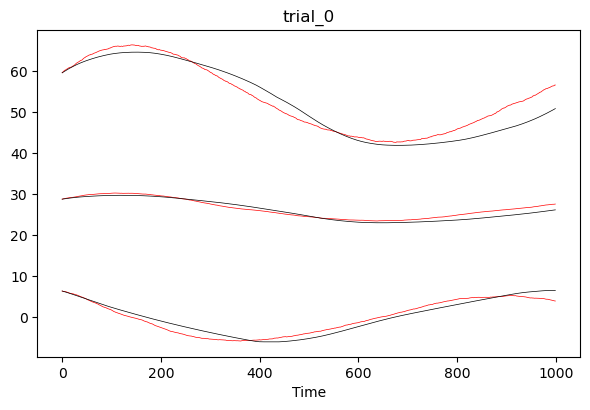

In [22]:
trial_plot = 0
plotTraj(data_raw[trial_plot], data_sim = curr_tau_trajs[trial_plot,:,:], title = 'trial_' + str(trial_plot))

# 2. covariate (time), no x0_tau

In [23]:
folder = 'out/test/00001-Cov_nox0-prr-uncond-regularFM-gpus1-batch256-fp32-with_covariates'
pkl_path = folder + '/network-snapshot-100000.pkl'

In [24]:
dataset_samples = np.load(folder + "/dataset_samples.npz", allow_pickle=True)
data_raw = dataset_samples['samples']
with open(pkl_path, 'rb') as f:
    model_all = pickle.load(f)

if 'ema' in model_all:
    net = model_all['ema']  # EMA-stabilized model (recommended for inference/simulation)
else:
    net = model_all['net']  # Raw trained model

net = net.to(device).eval()
flow_net = net.unet_model  # Compressive flow (u_theta)
dyn_net = net.vnet_model   # Dynamics flow (v_theta)
encoder = net.encoder      # For latent proposals

In [26]:
starting_pts = np.zeros((len(data_raw), data_raw[0].shape[1]))
for ii in range(len(data_raw)):
    starting_pts[ii,:] = data_raw[ii][0,:]
starting_pts = torch.from_numpy(starting_pts).unsqueeze(1).type(torch.float32).to(device) #ntrajs,1,dim

cov_dynamic_samples = []
for ii in range(len(data_raw)):
    cov_dynamic_samples.append(np.arange(data_raw[ii].shape[0])[:,None]*dt)
cov_static_samples = None

curr_tau_pts = starting_pts
n_step = T_min
tau = 1.0
curr_tau_trajs = []
curr_tau_trajs.append(curr_tau_pts.cpu().numpy())
include_x0_tau = False

for ii in tqdm(range(n_step-1)):

    covariates = torch.stack([torch.tensor(cov_dynamic_samples[jj][ii], dtype=torch.float32) for jj in range(len(cov_dynamic_samples))]).to(curr_tau_pts.device) if net.dim_cov_dynamic > 0 else None
    next_covariates = torch.stack([torch.tensor(cov_dynamic_samples[jj][ii+1], dtype=torch.float32) for jj in range(len(cov_dynamic_samples))]).to(curr_tau_pts.device) if net.dim_cov_dynamic > 0 else None

    if net.dim_cov_static > 0 and cov_static_samples is not None:
        if isinstance(cov_static_samples, np.ndarray):
            covariates_static = torch.tensor(cov_static_samples, dtype=torch.float32).to(curr_tau_pts.device)
        else:
            covariates_static = torch.stack([torch.tensor(cov_static_samples[jj][ii],
                                                          dtype=torch.float32) 
                                            for jj in range(len(cov_static_samples))]).to(curr_tau_pts.device)
    else:
        covariates_static = None

    
    x0_tau = curr_tau_pts.squeeze(1) # Current points become the starting points for this dynamics step
    curr_tau_pts = util.calc_dyn_trajectories(dyn_net, curr_tau_pts.squeeze(1),
                                               tau, x0_tau=x0_tau, 
                                               covariates=covariates,
                                               next_covariates=next_covariates,
                                               covariates_static=covariates_static,
                                               include_x0_tau=include_x0_tau, nt=2)
    curr_tau_pts = curr_tau_pts[-1].unsqueeze(1)
    curr_tau_trajs.append(curr_tau_pts.cpu().numpy())
   
curr_tau_trajs = np.concatenate(curr_tau_trajs, axis=1)

100%|████████████████████████████████████████| 999/999 [00:07<00:00, 137.11it/s]


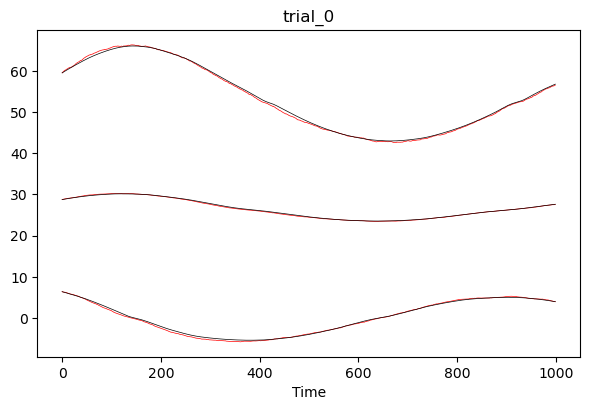

In [27]:
trial_plot = 0
plotTraj(data_raw[trial_plot], data_sim = curr_tau_trajs[trial_plot,:,:], title = 'trial_' + str(trial_plot))

# 3. no covariate (time), x0_tau

In [4]:
folder = 'out/test/00005-noCov_x0-prr-uncond-regularFM-gpus1-batch256-fp32-with_covariates'
pkl_path = folder + '/network-snapshot-070246.pkl'

In [5]:
dataset_samples = np.load(folder + "/dataset_samples.npz", allow_pickle=True)
data_raw = dataset_samples['samples']
with open(pkl_path, 'rb') as f:
    model_all = pickle.load(f)

if 'ema' in model_all:
    net = model_all['ema']  # EMA-stabilized model (recommended for inference/simulation)
else:
    net = model_all['net']  # Raw trained model

net = net.to(device).eval()
flow_net = net.unet_model  # Compressive flow (u_theta)
dyn_net = net.vnet_model   # Dynamics flow (v_theta)
encoder = net.encoder      # For latent proposals

In [6]:
starting_pts = np.zeros((len(data_raw), data_raw[0].shape[1]))
for ii in range(len(data_raw)):
    starting_pts[ii,:] = data_raw[ii][0,:]
starting_pts = torch.from_numpy(starting_pts).unsqueeze(1).type(torch.float32).to(device) #ntrajs,1,dim

cov_dynamic_samples = None
cov_static_samples = None

curr_tau_pts = starting_pts
n_step = T_min
tau = 1.0
curr_tau_trajs = []
curr_tau_trajs.append(curr_tau_pts.cpu().numpy())
include_x0_tau = True

for ii in tqdm(range(n_step-1)):

    covariates = torch.stack([torch.tensor(cov_dynamic_samples[jj][ii], dtype=torch.float32) for jj in range(len(cov_dynamic_samples))]).to(curr_tau_pts.device) if net.dim_cov_dynamic > 0 else None
    next_covariates = torch.stack([torch.tensor(cov_dynamic_samples[jj][ii+1], dtype=torch.float32) for jj in range(len(cov_dynamic_samples))]).to(curr_tau_pts.device) if net.dim_cov_dynamic > 0 else None

    if net.dim_cov_static > 0 and cov_static_samples is not None:
        if isinstance(cov_static_samples, np.ndarray):
            covariates_static = torch.tensor(cov_static_samples, dtype=torch.float32).to(curr_tau_pts.device)
        else:
            covariates_static = torch.stack([torch.tensor(cov_static_samples[jj][ii],
                                                          dtype=torch.float32) 
                                            for jj in range(len(cov_static_samples))]).to(curr_tau_pts.device)
    else:
        covariates_static = None

    
    x0_tau = curr_tau_pts.squeeze(1) # Current points become the starting points for this dynamics step
    curr_tau_pts = util.calc_dyn_trajectories(dyn_net, curr_tau_pts.squeeze(1),
                                               tau, x0_tau=x0_tau, 
                                               covariates=covariates,
                                               next_covariates=next_covariates,
                                               covariates_static=covariates_static,
                                               include_x0_tau=include_x0_tau, nt=2)
    curr_tau_pts = curr_tau_pts[-1].unsqueeze(1)
    curr_tau_trajs.append(curr_tau_pts.cpu().numpy())
   
curr_tau_trajs = np.concatenate(curr_tau_trajs, axis=1)

100%|█████████████████████████████████████████| 999/999 [00:18<00:00, 55.29it/s]


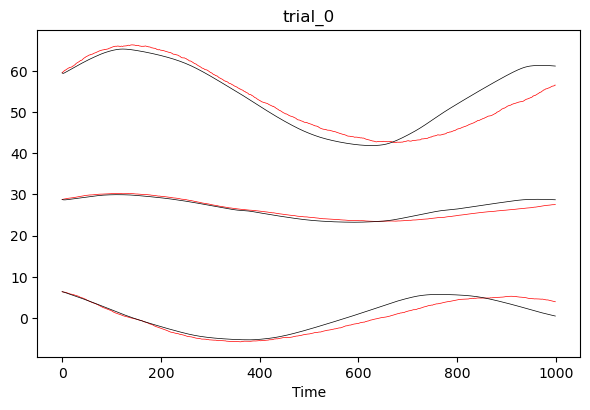

In [7]:
trial_plot = 0
plotTraj(data_raw[trial_plot], data_sim = curr_tau_trajs[trial_plot,:,:], title = 'trial_' + str(trial_plot))

# 4. covariate (time), x0_tau

In [33]:
folder = 'out/test/00003-Cov_x0-prr-uncond-regularFM-gpus1-batch256-fp32-with_covariates'
pkl_path = folder + '/network-snapshot-100000.pkl'

In [34]:
dataset_samples = np.load(folder + "/dataset_samples.npz", allow_pickle=True)
data_raw = dataset_samples['samples']
with open(pkl_path, 'rb') as f:
    model_all = pickle.load(f)

if 'ema' in model_all:
    net = model_all['ema']  # EMA-stabilized model (recommended for inference/simulation)
else:
    net = model_all['net']  # Raw trained model

net = net.to(device).eval()
flow_net = net.unet_model  # Compressive flow (u_theta)
dyn_net = net.vnet_model   # Dynamics flow (v_theta)
encoder = net.encoder      # For latent proposals

In [35]:
starting_pts = np.zeros((len(data_raw), data_raw[0].shape[1]))
for ii in range(len(data_raw)):
    starting_pts[ii,:] = data_raw[ii][0,:]
starting_pts = torch.from_numpy(starting_pts).unsqueeze(1).type(torch.float32).to(device) #ntrajs,1,dim

cov_dynamic_samples = []
for ii in range(len(data_raw)):
    cov_dynamic_samples.append(np.arange(data_raw[ii].shape[0])[:,None]*dt)
cov_static_samples = None

curr_tau_pts = starting_pts
n_step = T_min
tau = 1.0
curr_tau_trajs = []
curr_tau_trajs.append(curr_tau_pts.cpu().numpy())
include_x0_tau = True

for ii in tqdm(range(n_step-1)):

    covariates = torch.stack([torch.tensor(cov_dynamic_samples[jj][ii], dtype=torch.float32) for jj in range(len(cov_dynamic_samples))]).to(curr_tau_pts.device) if net.dim_cov_dynamic > 0 else None
    next_covariates = torch.stack([torch.tensor(cov_dynamic_samples[jj][ii+1], dtype=torch.float32) for jj in range(len(cov_dynamic_samples))]).to(curr_tau_pts.device) if net.dim_cov_dynamic > 0 else None

    if net.dim_cov_static > 0 and cov_static_samples is not None:
        if isinstance(cov_static_samples, np.ndarray):
            covariates_static = torch.tensor(cov_static_samples, dtype=torch.float32).to(curr_tau_pts.device)
        else:
            covariates_static = torch.stack([torch.tensor(cov_static_samples[jj][ii],
                                                          dtype=torch.float32) 
                                            for jj in range(len(cov_static_samples))]).to(curr_tau_pts.device)
    else:
        covariates_static = None

    
    x0_tau = curr_tau_pts.squeeze(1) # Current points become the starting points for this dynamics step
    curr_tau_pts = util.calc_dyn_trajectories(dyn_net, curr_tau_pts.squeeze(1),
                                               tau, x0_tau=x0_tau, 
                                               covariates=covariates,
                                               next_covariates=next_covariates,
                                               covariates_static=covariates_static,
                                               include_x0_tau=include_x0_tau, nt=2)
    curr_tau_pts = curr_tau_pts[-1].unsqueeze(1)
    curr_tau_trajs.append(curr_tau_pts.cpu().numpy())
   
curr_tau_trajs = np.concatenate(curr_tau_trajs, axis=1)

100%|████████████████████████████████████████| 999/999 [00:09<00:00, 106.64it/s]


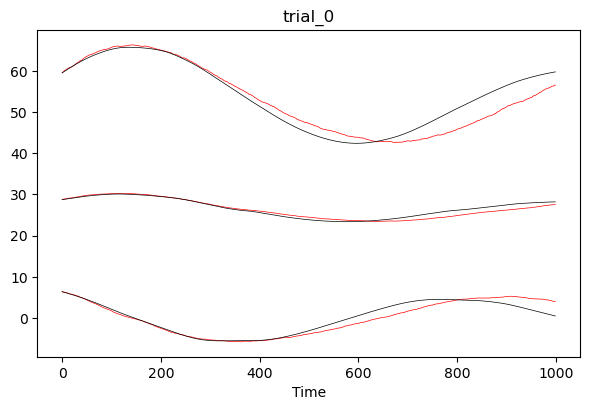

In [36]:
trial_plot = 0
plotTraj(data_raw[trial_plot], data_sim = curr_tau_trajs[trial_plot,:,:], title = 'trial_' + str(trial_plot))